<a href="https://colab.research.google.com/github/Mansik-04/assignments/blob/main/decision%20tree%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. What is a Decision Tree, and how does it work?

A Decision Tree is a supervised learning algorithm used for classification and regression tasks.

It splits data into subsets based on feature values.

At each node, the algorithm selects the best attribute and splitting criterion (Gini, Entropy, etc.) to maximize information gain.

The process continues recursively until stopping conditions (max depth, purity, etc.) are met.

The final result is a tree structure where each leaf node represents a decision outcome (class/continuous value).

2. What are impurity measures in Decision Trees?

Impurity measures indicate how mixed the classes are within a node. Common measures:

Gini Impurity

Entropy (Information Gain)

Classification Error

The goal is to minimize impurity when splitting nodes.
6. Difference between Gini Impurity and Entropy

Gini: Faster to compute, tends to favor the most frequent class.

Entropy: Uses logarithms, more sensitive to class distribution.
Both usually give similar results.

7. Mathematical explanation behind Decision Trees

Decision Trees use recursive binary partitioning.

At each node, they calculate impurity for all features.

The feature with the highest information gain (or lowest impurity) is selected.

Recursion continues until stop criteria are met.

8. Pre-Pruning

Stopping the tree growth early by setting constraints like:

max_depth

min_samples_split

min_samples_leaf

9. Post-Pruning

First, grow a full tree, then remove branches that don’t improve accuracy using techniques like Cost Complexity Pruning.

10. Difference between Pre- and Post-Pruning

Pre-Pruning: Stops early (before overfitting).

Post-Pruning: Removes extra nodes after full growth.

11. Decision Tree Regressor

A tree model that predicts continuous values instead of class labels. Uses MSE or MAE as impurity measure.

12. Advantages & Disadvantages

✅ Easy to interpret
✅ Handles categorical & numerical data
✅ No feature scaling needed

❌ Prone to overfitting
❌ Unstable (small changes → different trees)
❌ Biased with imbalanced data

13. Handling Missing Values

Surrogate splits

Assigning to the most frequent class

Ignoring missing values during split calculation

14. Handling Categorical Features

Splits based on categories (e.g., “Red/Blue/Green”)

One-hot encoding if needed

15. Real-world Applications

Medical diagnosis

Credit scoring

Fraud detection

Marketing segmentation

Model Accuracy (Default Criterion): 1.0
Feature Importances (Gini): [0.         0.01667014 0.90614339 0.07718647]
Model Accuracy (Entropy): 1.0
MSE (Regressor): 0.495235205629094


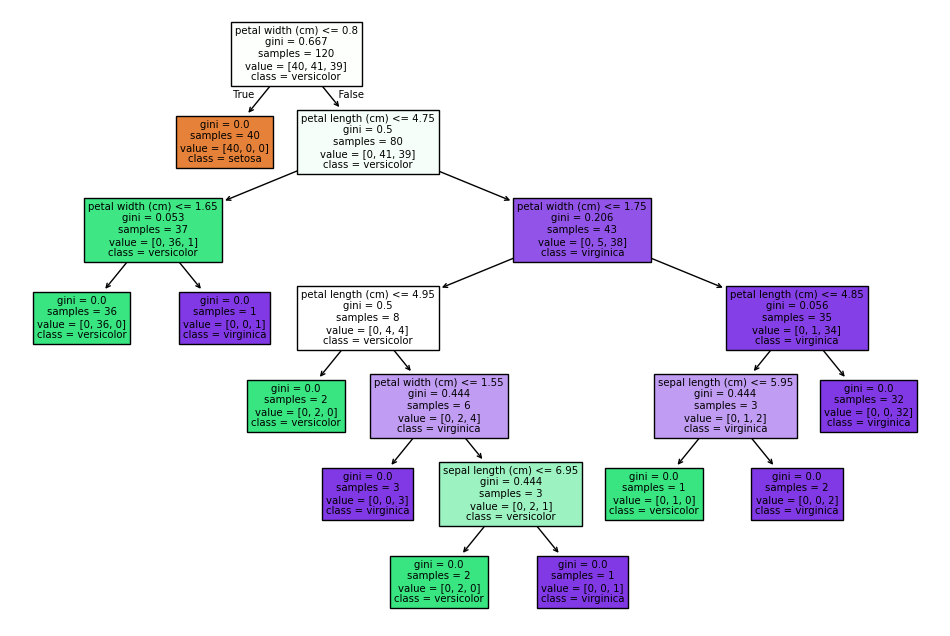

Accuracy with max_depth=3: 1.0
Accuracy with full tree: 1.0
Accuracy with min_samples_split=5: 1.0
Accuracy with scaled features: 1.0
OvR Accuracy: 1.0
Feature Importances: [0.03334028 0.         0.38926487 0.57739485]
MSE with max_depth=5: 0.5245146178314735
MSE with unrestricted tree: 0.495235205629094


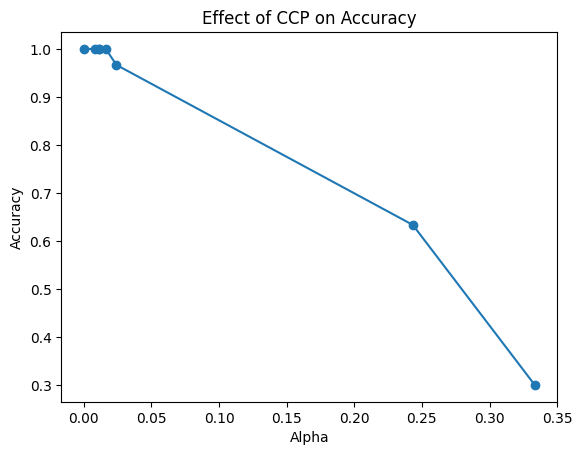

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



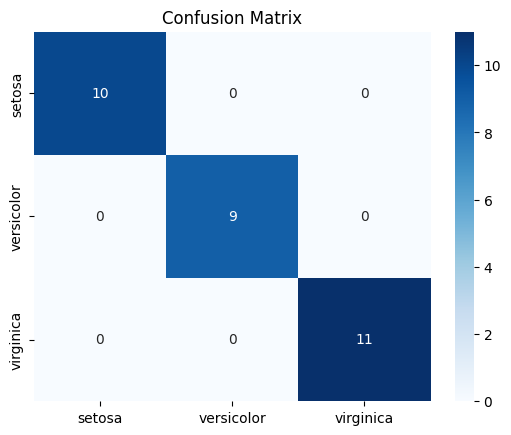

Best Parameters from GridSearchCV: {'max_depth': 4, 'min_samples_split': 2}
Best Accuracy: 0.9416666666666668


In [1]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Train Decision Tree Classifier on Iris dataset
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Model Accuracy (Default Criterion):", accuracy_score(y_test, y_pred))

# 2. Using Gini Impurity
clf_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
clf_gini.fit(X_train, y_train)
print("Feature Importances (Gini):", clf_gini.feature_importances_)

# 3. Using Entropy
clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
clf_entropy.fit(X_train, y_train)
y_pred_entropy = clf_entropy.predict(X_test)
print("Model Accuracy (Entropy):", accuracy_score(y_test, y_pred_entropy))

# 4. Decision Tree Regressor on Housing dataset
housing = fetch_california_housing()
Xh, yh = housing.data, housing.target
Xh_train, Xh_test, yh_train, yh_test = train_test_split(Xh, yh, test_size=0.2, random_state=42)
reg = DecisionTreeRegressor(random_state=42)
reg.fit(Xh_train, yh_train)
yh_pred = reg.predict(Xh_test)
print("MSE (Regressor):", mean_squared_error(yh_test, yh_pred))

# 5. Visualize Tree
plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

# 6. Compare max_depth=3 vs full tree
clf3 = DecisionTreeClassifier(max_depth=3, random_state=42)
clf3.fit(X_train, y_train)
print("Accuracy with max_depth=3:", accuracy_score(y_test, clf3.predict(X_test)))
print("Accuracy with full tree:", accuracy_score(y_test, clf.predict(X_test)))

# 7. min_samples_split=5
clf_min = DecisionTreeClassifier(min_samples_split=5, random_state=42)
clf_min.fit(X_train, y_train)
print("Accuracy with min_samples_split=5:", accuracy_score(y_test, clf_min.predict(X_test)))

# 8. Feature scaling (Decision Trees don’t need scaling but for comparison)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
clf_scaled = DecisionTreeClassifier(random_state=42)
clf_scaled.fit(X_train_s, y_train_s)
print("Accuracy with scaled features:", accuracy_score(y_test_s, clf_scaled.predict(X_test_s)))

# 9. One-vs-Rest (OvR)
from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(DecisionTreeClassifier(random_state=42))
ovr_clf.fit(X_train, y_train)
print("OvR Accuracy:", accuracy_score(y_test, ovr_clf.predict(X_test)))

# 10. Feature importance scores
print("Feature Importances:", clf.feature_importances_)

# 11. Regressor with max_depth=5 vs unrestricted
reg5 = DecisionTreeRegressor(max_depth=5, random_state=42)
reg5.fit(Xh_train, yh_train)
print("MSE with max_depth=5:", mean_squared_error(yh_test, reg5.predict(Xh_test)))
print("MSE with unrestricted tree:", mean_squared_error(yh_test, yh_pred))

# 12. Cost Complexity Pruning
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
clfs = [DecisionTreeClassifier(random_state=42, ccp_alpha=alpha).fit(X_train, y_train) for alpha in ccp_alphas]
acc_scores = [accuracy_score(y_test, model.predict(X_test)) for model in clfs]
plt.plot(ccp_alphas, acc_scores, marker='o')
plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.title("Effect of CCP on Accuracy")
plt.show()

# 13. Precision, Recall, F1
print("Classification Report:\n", classification_report(y_test, y_pred))

# 14. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Confusion Matrix")
plt.show()

# 15. GridSearchCV for optimal parameters
param_grid = {"max_depth": [2, 3, 4, None], "min_samples_split": [2, 5, 10]}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best Parameters from GridSearchCV:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)
